In [1]:
# !unzip /content/drive/MyDrive/LLCP2024XPT.zip # source the BRFSS dataset
!pip install imbalanced-learn xgboost

Archive:  /content/drive/MyDrive/LLCP2024XPT.zip
  inflating: LLCP2024.XPT            


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import tensorflow as tf
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, precision_score, recall_score, f1_score, average_precision_score
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler

In [3]:
df = pd.read_sas(os.path.join(os.getcwd(), 'LLCP2024.XPT '), format="xport")

In [4]:
cols = [
    # Target
    'DIABETE4',    # Diabetes diagnosis

    # Core predictors
    '_BMI5',       # BMI
    '_AGEG5YR',    # Age (5-year categories)
    'SEXVAR',      # Sex
    'GENHLTH',     # General health (self-reported)

    # Blood pressure & cholesterol — no direct flags in 2024, using proxies
    'CVDINFR4',    # Heart attack history
    'CVDCRHD4',    # Coronary heart disease
    'CVDSTRK3',    # Stroke history

    # Physical & mental health
    'PHYSHLTH',    # Days physical health not good
    'MENTHLTH',    # Days mental health not good
    'POORHLTH',    # Days poor health kept you from usual activities

    # Functional
    'DIFFWALK',    # Difficulty walking
    'DECIDE',      # Difficulty concentrating/remembering

    # Lifestyle
    '_TOTINDA',    # Physical activity
    '_SMOKER3',    # Smoking status
    '_RFDRHV9',    # Heavy alcohol consumption (2024 version)
    'EXERANY2',    # Exercise in past 30 days

    # Socioeconomic
    '_INCOMG1',    # Income level
    '_EDUCAG',     # Education level
    '_HCVU654',    # Health coverage
    'MEDCOST1',    # Could not see doctor due to cost
    'CHECKUP1',    # Last routine checkup

    # Comorbidities
    'CHCKDNY2',    # Kidney disease
    'ADDEPEV3',    # Depression
    'HAVARTH4',    # Arthritis
    'CHCCOPD3',    # COPD
]

df_diabetes = df[cols].copy()
print(df_diabetes.shape)
print(df_diabetes['DIABETE4'].value_counts())

(457670, 26)
DIABETE4
3.0    376125
1.0     65809
4.0     11307
2.0      3395
7.0       798
9.0       232
Name: count, dtype: int64


# Preprocessing the Data

In [5]:
df_diabetes = df_diabetes[~df_diabetes['DIABETE4'].isin([7.0, 9.0])]
print(df_diabetes['DIABETE4'].value_counts())

DIABETE4
3.0    376125
1.0     65809
4.0     11307
2.0      3395
Name: count, dtype: int64


In [6]:
df_diabetes["Diabetes_binary"] = df_diabetes["DIABETE4"].isin([1.0, 4.0]).astype(int)
df_diabetes = df_diabetes.drop('DIABETE4', axis=1)

In [7]:
X = df_diabetes.drop('Diabetes_binary', axis=1)
y = df_diabetes['Diabetes_binary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

Drop poor columns

In [8]:
X_train = X_train.drop('POORHLTH', axis=1)
X_test = X_test.drop('POORHLTH', axis=1)
X_train = X_train.drop('_HCVU654', axis=1)
X_test = X_test.drop('_HCVU654', axis=1)

Fill in Columns where 7,9 and other special nums are invalid codes

In [9]:
cols_7_9 = [
    'GENHLTH', 'CVDINFR4', 'CVDCRHD4', 'CVDSTRK3',
    'DIFFWALK', 'DECIDE', 'MEDCOST1', 'CHECKUP1',
    'CHCKDNY2', 'ADDEPEV3', 'HAVARTH4', 'CHCCOPD3',
    'EXERANY2'
]

for col in cols_7_9:
    if col in df_diabetes.columns:
        X_train[col] = X_train[col].replace([7.0, 9.0], pd.NA)
        X_test[col] = X_test[col].replace([7.0, 9.0], pd.NA)
        fill_value = X_train[col].mode()[0]
        X_train[col] = X_train[col].fillna(fill_value)
        X_test[col] = X_test[col].fillna(fill_value)

cols_9_only = ['_INCOMG1', '_EDUCAG', '_TOTINDA', '_RFDRHV9', '_SMOKER3']

for col in cols_9_only:
    if col in df_diabetes.columns:
        X_train[col] = X_train[col].replace([9.0], pd.NA)
        X_test[col] = X_test[col].replace([9.0], pd.NA)
        fill_value = X_train[col].mode()[0]
        X_train[col] = X_train[col].fillna(fill_value)
        X_test[col] = X_test[col].fillna(fill_value)

special_cols = {'_AGEG5YR': 14.0}
for col, value in special_cols.items():
    if col in df_diabetes.columns:
        X_train[col] = X_train[col].replace([value], pd.NA)
        X_test[col] = X_test[col].replace([value], pd.NA)
        fill_value = X_train[col].mode()[0]
        X_train[col] = X_train[col].fillna(fill_value)
        X_test[col] = X_test[col].fillna(fill_value)

/tmp/ipykernel_740/3365831410.py:13: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_train[col] = X_train[col].fillna(fill_value)
/tmp/ipykernel_740/3365831410.py:14: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_test[col] = X_test[col].fillna(fill_value)
/tmp/ipykernel_740/3365831410.py:23: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
 

In [10]:
X_train.isnull().sum()
X_test.isnull().sum()


,0
_BMI5,8589
_AGEG5YR,0
SEXVAR,0
GENHLTH,0
CVDINFR4,0
CVDCRHD4,0
CVDSTRK3,0
PHYSHLTH,0
MENTHLTH,0
DIFFWALK,0


Handle BMI, physical health and mental hlth

In [11]:
X_train.fillna({'_BMI5': X_train['_BMI5'].median()}, inplace=True)
X_test.fillna({'_BMI5': X_train['_BMI5'].median()}, inplace=True)
X_train['_BMI5'] = X_train['_BMI5'] * 0.01
X_test['_BMI5'] = X_test['_BMI5'] * 0.01

In [12]:
X_train['PHYSHLTH'] = X_train['PHYSHLTH'].replace({88.0: 0, 99.0: None, 77.0: None})
X_test['PHYSHLTH'] = X_test['PHYSHLTH'].replace({88.0: 0, 99.0: None, 77.0: None})

X_train['MENTHLTH'] = X_train['MENTHLTH'].replace({88.0: 0, 99.0: None, 77.0: None})
X_test['MENTHLTH'] = X_test['MENTHLTH'].replace({88.0: 0, 99.0: None, 77.0: None})

physhlth_median = X_train['PHYSHLTH'].median()
menthlth_median = X_train['MENTHLTH'].median()

X_train['PHYSHLTH'] = X_train['PHYSHLTH'].fillna(physhlth_median)
X_test['PHYSHLTH'] = X_test['PHYSHLTH'].fillna(physhlth_median)

X_train['MENTHLTH'] = X_train['MENTHLTH'].fillna(menthlth_median)
X_test['MENTHLTH'] = X_test['MENTHLTH'].fillna(menthlth_median)

/tmp/ipykernel_740/4070251638.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_train['PHYSHLTH'] = X_train['PHYSHLTH'].replace({88.0: 0, 99.0: None, 77.0: None})
/tmp/ipykernel_740/4070251638.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_test['PHYSHLTH'] = X_test['PHYSHLTH'].replace({88.0: 0, 99.0: None, 77.0: None})
/tmp/ipykernel_740/4070251638.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_object

In [13]:
X_train.describe()

,_BMI5,_AGEG5YR,SEXVAR,GENHLTH,CVDINFR4,CVDCRHD4,CVDSTRK3,PHYSHLTH,MENTHLTH,DIFFWALK,...,_RFDRHV9,EXERANY2,_INCOMG1,_EDUCAG,MEDCOST1,CHECKUP1,CHCKDNY2,ADDEPEV3,HAVARTH4,CHCCOPD3
count,365312.000000,365312.000000,365312.000000,365312.000000,365312.000000,365312.000000,365312.000000,365312.000000,365312.000000,365312.000000,...,365312.000000,365312.000000,365312.000000,365312.000000,365312.000000,365312.000000,365312.000000,365312.000000,365312.000000,365312.000000
mean,28.451792,7.708589,1.524374,2.644986,1.941354,1.937599,1.955099,4.491925,4.330991,1.844174,...,1.052801,1.231796,4.617727,3.052834,1.905412,1.343528,1.947976,1.790212,1.654055,1.919222
std,6.268083,3.654003,0.499406,1.046445,0.234961,0.241884,0.207088,8.840018,8.302909,0.362691,...,0.223637,0.421980,1.467660,0.953945,0.292645,0.904714,0.222076,0.407158,0.475676,0.272494
min,12.050000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,24.410000,5.000000,1.000000,2.000000,2.000000,2.000000,2.000000,0.000000,0.000000,2.000000,...,1.000000,1.000000,4.000000,2.000000,2.000000,1.000000,2.000000,2.000000,1.000000,2.000000
50%,27.440000,8.000000,2.000000,3.000000,2.000000,2.000000,2.000000,0.000000,0.000000,2.000000,...,1.000000,1.000000,5.000000,3.000000,2.000000,1.000000,2.000000,2.000000,2.000000,2.000000
75%,31.190000,11.000000,2.000000,3.000000,2.000000,2.000000,2.000000,4.000000,5.000000,2.000000,...,1.000000,1.000000,5.000000,4.000000,2.000000,1.000000,2.000000,2.000000,2.000000,2.000000
max,99.840000,13.000000,2.000000,5.000000,2.000000,2.000000,2.000000,30.000000,30.000000,2.000000,...,2.000000,2.000000,7.000000,4.000000,2.000000,8.000000,2.000000,2.000000,2.000000,2.000000


# Exploring the Data

/tmp/ipykernel_1510/2852831098.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_diabetes, x='Diabetes_binary', palette='pastel')


<Axes: xlabel='Diabetes_binary', ylabel='count'>

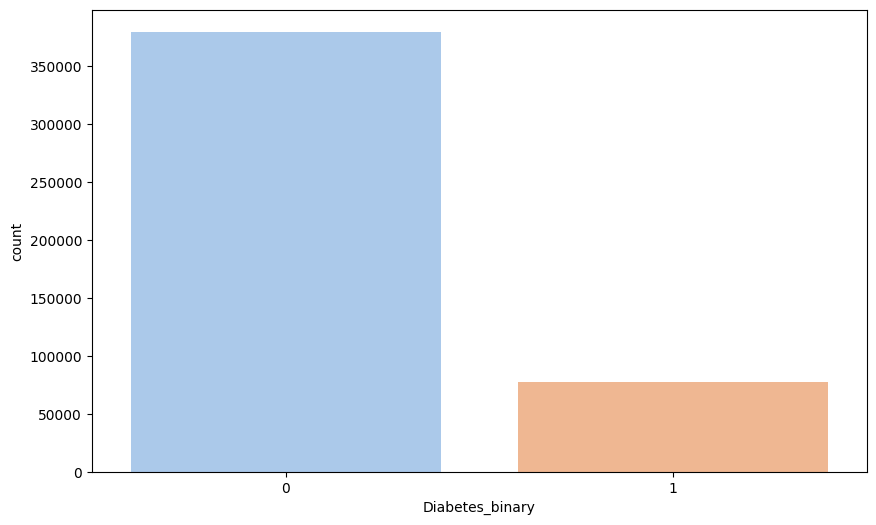

In [40]:
# bar chart of diabetic class distribution
plt.figure(figsize=(10, 6))
sns.countplot(data=df_diabetes, x='Diabetes_binary', palette='pastel')

<Axes: xlabel='_BMI5', ylabel='Count'>

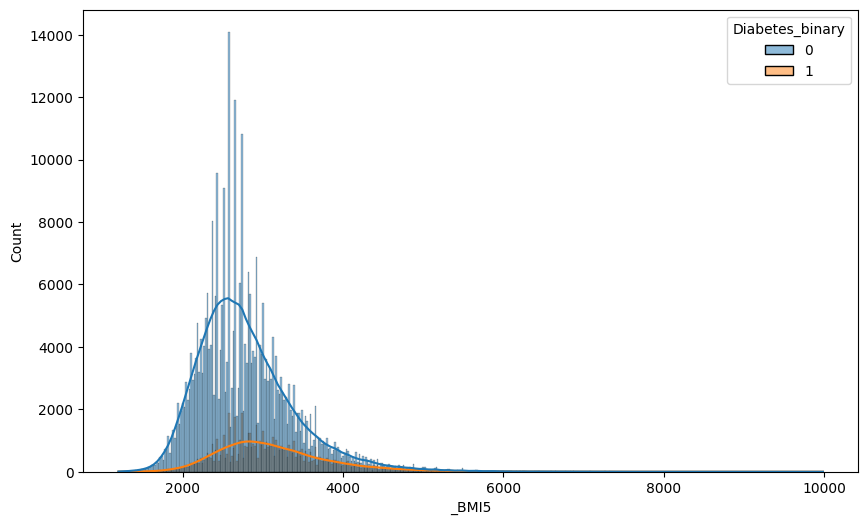

In [37]:
# bmi distribution
plt.figure(figsize=(10, 6))
sns.histplot(data=df_diabetes, x='_BMI5', hue='Diabetes_binary', kde=True)

<Axes: xlabel='_AGEG5YR', ylabel='count'>

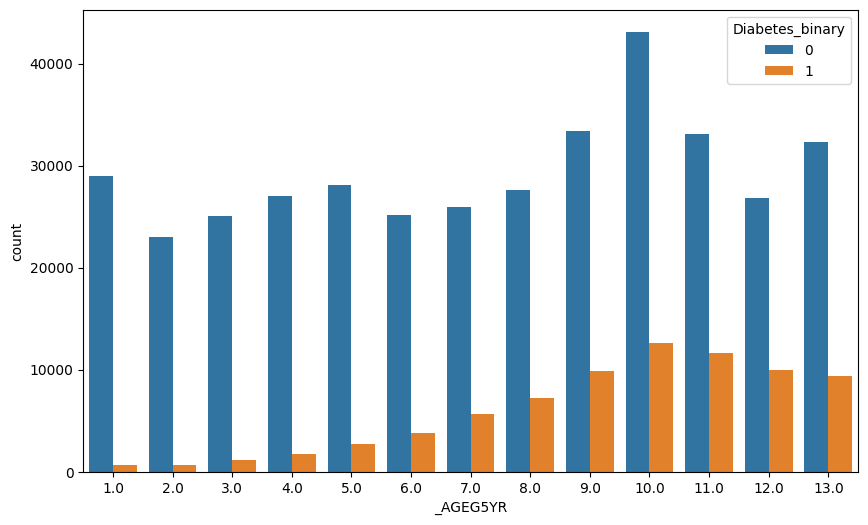

In [18]:
# count plot of _AGEG5YR split by diabetic stati
plt.figure(figsize=(10, 6))
sns.countplot(data=df_diabetes, x='_AGEG5YR', hue='Diabetes_binary')

<Axes: >

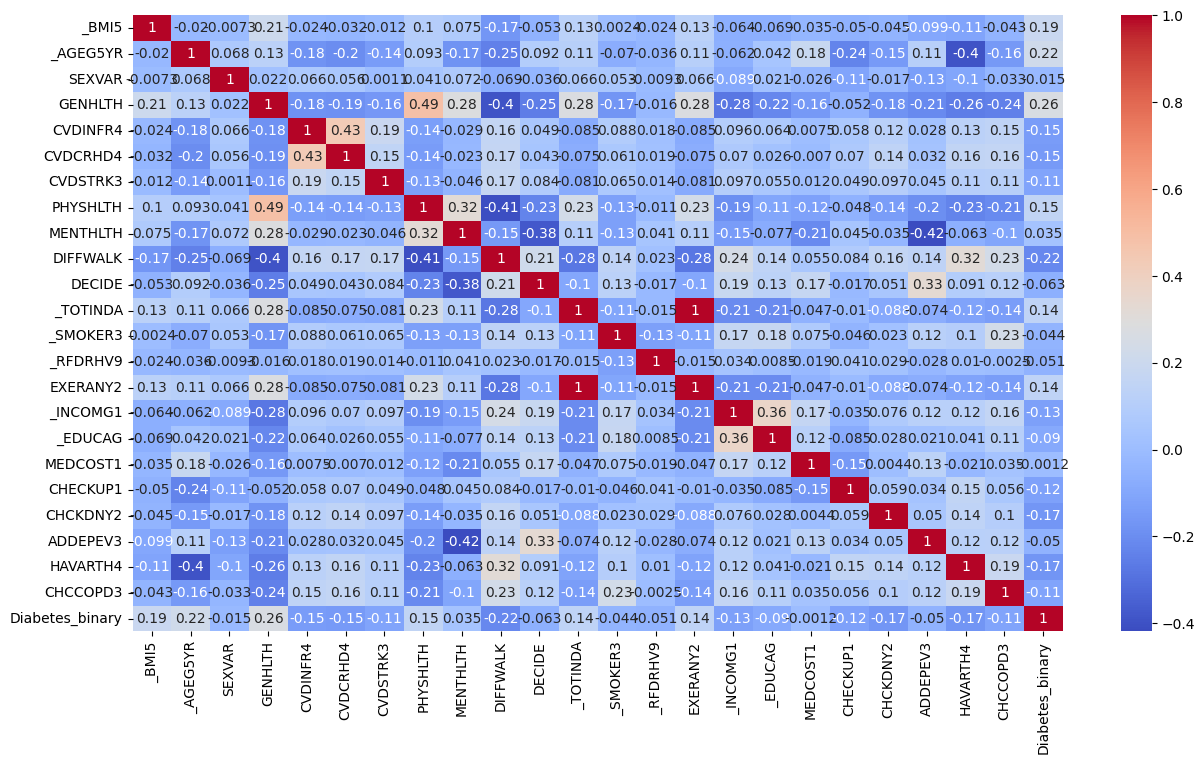

In [19]:
# correlation heatmap
plt.figure(figsize=(15, 8))
sns.heatmap(df_diabetes.corr(), annot=True, cmap='coolwarm')

# Data Modeling

### XGBoost Classifier Model

In [14]:
xg_model = XGBClassifier(
    n_estimators=170,       # Number of gradient boosted trees
    learning_rate=0.05,     # Step size shrinkage to prevent overfitting
    max_depth=5,            # Maximum tree depth for base learners
    subsample=0.8,          # Fraction of samples to be randomly sampled per tree
    eval_metric='logloss',  # Evaluation metric for binary classification
    random_state=42,
    n_jobs=-1
    # tree_method='gpu_hist', # Use GPU for tree construction
    # predictor='gpu_predictor' # Use GPU for prediction
)
xg_model.fit(X_train, y_train)

y_pred_lr = xg_model.predict(X_test)
y_proba_lr = xg_model.predict_proba(X_test)[:, 1]

print("XGBoost Model Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))
print(f"ROC AUC Score: {roc_auc_score(y_test, y_proba_lr):.4f}")


XGBoost Model Evaluation:
Accuracy: 0.8395

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.98      0.91     75905
           1       0.59      0.16      0.25     15423

    accuracy                           0.84     91328
   macro avg       0.72      0.57      0.58     91328
weighted avg       0.81      0.84      0.80     91328

ROC AUC Score: 0.8070


In [15]:
scale_pos_weight = (
    y_train.value_counts()[0] /
    y_train.value_counts()[1]
)

print(scale_pos_weight)

4.921449759291978


In [16]:
param_grid = {
    'n_estimators': [100, 150, 200, 300, 400, 500],
    'learning_rate': [0.01, 0.03, 0.05, 0.075, 0.1],
    'max_depth': [3, 4, 5, 6, 7],
    'min_child_weight': [1, 3, 5, 7],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0]
}

In [18]:
xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    tree_method='hist',
    device='cuda',
    random_state=42,
    scale_pos_weight=scale_pos_weight,
    n_jobs=-1
)

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid,
    # scale_pos_weight=scale_pos_weight,
    n_iter=50,
    scoring='average_precision',
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=3
)

random_search.fit(X_train, y_train)

print("Best Parameters:")
print(random_search.best_params_)

print("\nBest CV ROC-AUC:")
print(random_search.best_score_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Parameters:
{'subsample': 0.7, 'n_estimators': 500, 'min_child_weight': 7, 'max_depth': 6, 'learning_rate': 0.03, 'colsample_bytree': 0.7}

Best CV ROC-AUC:
0.4449391084070844


In [21]:
best_xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    tree_method='hist',
    device='cuda',
    scale_pos_weight=scale_pos_weight,


    subsample=0.7,
    n_estimators=500,
    min_child_weight=7,
    max_depth=6,
    learning_rate=0.03,
    colsample_bytree=0.7,

    random_state=42
)

best_xgb.fit(X_train, y_train)

y_pred = best_xgb.predict(X_test)
y_proba = best_xgb.predict_proba(X_test)[:, 1]

print("Tuned XGBoost Model Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print(f"ROC AUC Score: {roc_auc_score(y_test, y_proba):.4f}")

print(f"PR AUC Score: {average_precision_score(y_test, y_proba):.4f}")

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [05:06:33] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "threshold" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Tuned XGBoost Model Evaluation:
Accuracy: 0.6999

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.68      0.79     75905
           1       0.33      0.78      0.47     15423

    accuracy                           0.70     91328
   macro avg       0.64      0.73      0.63     91328
weighted avg       0.84      0.70      0.74     91328

ROC AUC Score: 0.8078
PR AUC Score: 0.4510


In [20]:
thresholds = [
    0.20, 0.25, 0.30, 0.35,
    0.40, 0.45, 0.50, 0.55,
    0.60, 0.65, 0.70
]

for threshold in thresholds:

    y_pred = (y_proba >= threshold).astype(int)

    print(
        f"Threshold: {threshold:.2f} | "
        f"Precision: {precision_score(y_test, y_pred):.3f} | "
        f"Recall: {recall_score(y_test, y_pred):.3f} | "
        f"F1: {f1_score(y_test, y_pred):.3f}"
    )

Threshold: 0.20 | Precision: 0.238 | Recall: 0.958 | F1: 0.381
Threshold: 0.25 | Precision: 0.252 | Recall: 0.942 | F1: 0.397
Threshold: 0.30 | Precision: 0.265 | Recall: 0.920 | F1: 0.412
Threshold: 0.35 | Precision: 0.280 | Recall: 0.897 | F1: 0.426
Threshold: 0.40 | Precision: 0.296 | Recall: 0.863 | F1: 0.441
Threshold: 0.45 | Precision: 0.313 | Recall: 0.826 | F1: 0.454
Threshold: 0.50 | Precision: 0.334 | Recall: 0.782 | F1: 0.468
Threshold: 0.55 | Precision: 0.358 | Recall: 0.725 | F1: 0.479
Threshold: 0.60 | Precision: 0.385 | Recall: 0.655 | F1: 0.485
Threshold: 0.65 | Precision: 0.417 | Recall: 0.569 | F1: 0.481
Threshold: 0.70 | Precision: 0.455 | Recall: 0.473 | F1: 0.464


Picking 0.40 as the threshold because we want to prioritize Recall (80+% range)

## Diabetes Risk Prediction Model

**Dataset:** CDC BRFSS 2024 (Behavioral Risk Factor Surveillance System), ~91K+
respondents, self-reported health/lifestyle survey data.

**Goal:** Diabetes diagnosis (`Diabetes_binary`), derived from `DIABETE4`.

**Features:** 20 predictors covering demographics (age, sex, income, education),
comorbidities (heart disease, stroke, kidney disease, depression, arthritis, COPD),
lifestyle (smoking, alcohol, exercise), and functional health (BMI, general health,
difficulty walking/concentrating).

**Preprocessing:**
- Split into train/test before any imputation to avoid data leakage.
- Invalid survey codes (7/9/refused-type responses) replaced with train-set mode/median only.
- Class imbalance handled via `scale_pos_weight`.

**Model:** XGBoost classifier, hyperparameters tuned via RandomizedSearchCV

**Results:**
- ROC-AUC: 0.81
- PR-AUC: 0.45
- Classification threshold: 0.40 (rather than default 0.50), prioritizing recall
  (~86%) since missing an at-risk individual is costlier than a false positive in
  a screening context.

**Note:** Performance is consistent with published results on BRFSS-based diabetes
prediction, given that self-reported survey data has an inherent ceiling on
separability compared to clinical/lab data.

In [22]:
import joblib
joblib.dump(best_xgb, 'diabetes_risk_model.pkl')

['diabetes_risk_model.pkl']